## Challenge

   Unnamed: 0       job_title   job_type experience_level       location  \
0           0  Data scientist  Full Time           Senior  New York City   
1           2  Data scientist  Full Time           Senior         Boston   
2           3  Data scientist  Full Time           Senior         London   
3           4  Data scientist  Full Time           Senior         Boston   
4           5  Data scientist  Full Time           Senior  New York City   

  salary_currency  salary  
0             USD  149000  
1             USD  120000  
2             USD   68000  
3             USD  120000  
4             USD  149000  
   salary  salary_normalized
0  149000           0.601010
1  120000           0.454545
2   68000           0.191919
3  120000           0.454545
4  149000           0.601010
            PC1         PC2
0  84163.766081 -949.193183
1  55163.767131 -941.138351
2   3163.768472 -929.281412
3  55163.767548 -939.138352
4  84163.767125 -944.193183


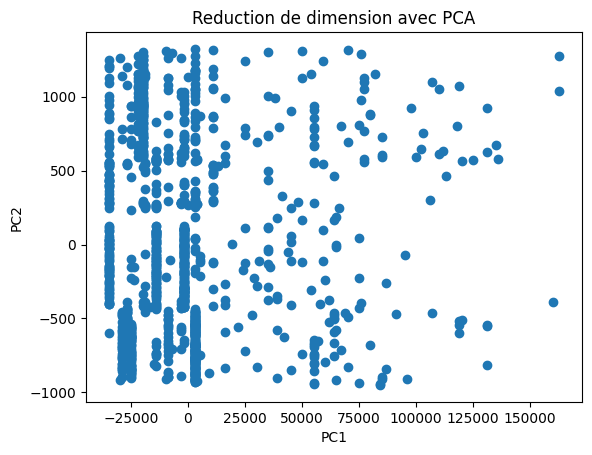

                          mean   median
experience_level                       
Entry             36111.111111  30000.0
Executive         76076.923077  46000.0
Mid               51786.885246  51000.0
Senior            75088.033012  68000.0


In [3]:
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Charger le fichier CSV
df = pd.read_csv("datascience_salaries.csv")

# Afficher les 5 premières lignes
print(df.head())

# Création du scaler
scaler = MinMaxScaler()

# Normalisation entre 0 et 1
df["salary_normalized"] = scaler.fit_transform(df[["salary"]])

# Affichage
print(df[["salary", "salary_normalized"]].head())


# Sélection des colonnes numériques
colonnes_numeriques = df.select_dtypes(include=["int64", "float64"])

# Création du modèle PCA
pca = PCA(n_components=2)

# Réduction des dimensions
pca_result = pca.fit_transform(colonnes_numeriques)

# Création d'un nouveau DataFrame
df_pca = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

# Affichage
print(df_pca.head())


plt.scatter(df_pca["PC1"], df_pca["PC2"])

plt.title("Reduction de dimension avec PCA")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

# Calcul du salaire moyen et median
salaire_experience = df.groupby(
    "experience_level"
)["salary"].agg(
    ["mean", "median"]
)

# Affichage
print(salaire_experience)
